In [2]:
# =============================================================
# CELL 1.1 — Imports & Environment Check
# Verifies GPU availability and imports all required libraries
# =============================================================

import os
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
from scipy.ndimage import zoom, rotate
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from imblearn.metrics import specificity_score

# ── Environment check ─────────────────────────────────────────
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"GPU:             {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device:          {device}")

PyTorch version: 2.5.1+cu121
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3070 Ti
Device:          cuda


In [3]:
# =============================================================
# CELL 1.2 — Cohort Loading & Data Split
# Loads the 210-subject cohort and creates stratified
# 60/20/20 train/val/test split matching Jamie's article
# =============================================================

# ── Paths ─────────────────────────────────────────────────────
FS_OUTPUT  = "E:/Oasis3/FastSurfer_output"   # FastSurfer segmentations
COHORT_CSV = "E:/Oasis3/thesis_cohort_final.csv"  # Subject labels
CACHE_DIR  = "D:/mamba_model/cache"          # Preprocessed data cache
CKPT_DIR   = "D:/mamba_model/checkpoints"    # Saved model weights

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,  exist_ok=True)

# ── Load cohort ───────────────────────────────────────────────
cohort = pd.read_csv(COHORT_CSV)
print(f"Total subjects:  {len(cohort)}")
print(f"Converters:      {cohort.outcome_label.sum()}")
print(f"Stable CN:       {(cohort.outcome_label==0).sum()}")

sessions = cohort['mri_session'].values
labels   = cohort['outcome_label'].values

# ── Stratified 60/20/20 split (same as Vo et al.) ────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    sessions, labels, test_size=0.2, random_state=42, stratify=labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

print(f"\nSplit (60/20/20):")
print(f"  Train: {len(X_train)}  (converters={y_train.sum()}, CN={(y_train==0).sum()})")
print(f"  Val:   {len(X_val)}   (converters={y_val.sum()}, CN={(y_val==0).sum()})")
print(f"  Test:  {len(X_test)}   (converters={y_test.sum()}, CN={(y_test==0).sum()})")

# ── Verify FastSurfer outputs exist ───────────────────────────
missing = []
for s in sessions:
    seg  = Path(f"{FS_OUTPUT}/{s}/mri/aparc.DKTatlas+aseg.deep.mgz")
    orig = Path(f"{FS_OUTPUT}/{s}/mri/orig.mgz")
    if not seg.exists() or not orig.exists():
        missing.append(s)

print(f"\nFastSurfer outputs: {len(sessions)-len(missing)}/{len(sessions)} present")
if missing:
    print(f"Missing: {missing}")

Total subjects:  210
Converters:      107
Stable CN:       103

Split (60/20/20):
  Train: 126  (converters=65, CN=61)
  Val:   42   (converters=21, CN=21)
  Test:  42   (converters=21, CN=21)

FastSurfer outputs: 210/210 present


In [4]:
# =============================================================
# CELL 2.1 — ROI Labels & Preprocessing Functions
# Defines the 6 anatomically-motivated ROI regions and
# preprocessing pipeline: mask → crop → z-score normalise → resize
#
# ROI selection rationale (Khan et al., 2023):
#   - Hippocampus:     primary site of early AD neurodegeneration
#   - Cerebellum WM:   affected in prodromal AD
#   - Cerebral WM:     white matter hyperintensities linked to conversion
# =============================================================

# ── ROI label IDs (FreeSurfer/FastSurfer LUT) ─────────────────
ROI_INFO = {
    'Left-Hippocampus':    17,
    'Right-Hippocampus':   53,
    'Left-Cerebellum-WM':   7,
    'Right-Cerebellum-WM': 46,
    'Left-Cerebral-WM':     2,
    'Right-Cerebral-WM':   41,
}
ROI_NAMES = list(ROI_INFO.keys())
ROI_SIZE  = (64, 64, 64)   # Each ROI resized to this after tight crop

# ── Preprocessing pipeline ────────────────────────────────────
def extract_roi_cropped(session_id, roi_size=ROI_SIZE):
    """
    For each of the 6 ROIs:
      1. Extract voxels belonging to that ROI from the segmentation
      2. Crop tightly around the ROI bounding box (+3 voxel padding)
      3. Z-score normalise using ROI voxels only (background stays 0)
      4. Resize to fixed roi_size using trilinear interpolation

    Returns: dict {roi_name: np.array of shape roi_size}
    """
    seg_path  = f"{FS_OUTPUT}/{session_id}/mri/aparc.DKTatlas+aseg.deep.mgz"
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"

    seg_data  = nib.load(seg_path).get_fdata()
    orig_data = nib.load(orig_path).get_fdata()

    rois = {}
    for roi_name, label_id in ROI_INFO.items():
        mask    = (seg_data == label_id)
        roi_vol = orig_data * mask

        # Tight crop
        coords = np.where(mask)
        if len(coords[0]) == 0:
            rois[roi_name] = np.zeros(roi_size, dtype=np.float32)
            continue

        pad = 3
        z1 = max(0, coords[0].min() - pad)
        z2 = min(seg_data.shape[0]-1, coords[0].max() + pad)
        y1 = max(0, coords[1].min() - pad)
        y2 = min(seg_data.shape[1]-1, coords[1].max() + pad)
        x1 = max(0, coords[2].min() - pad)
        x2 = min(seg_data.shape[2]-1, coords[2].max() + pad)

        cropped = roi_vol[z1:z2+1, y1:y2+1, x1:x2+1]

        # Z-score normalise (ROI voxels only)
        roi_voxels = cropped[cropped != 0]
        if len(roi_voxels) > 0 and roi_voxels.std() > 0:
            cropped = np.where(
                cropped != 0,
                (cropped - roi_voxels.mean()) / roi_voxels.std(),
                0
            )

        # Resize to fixed size
        zoom_factors = [t/s for t, s in zip(roi_size, cropped.shape)]
        resized = zoom(cropped, zoom_factors, order=1)
        rois[roi_name] = resized.astype(np.float32)

    return rois


# ── Quick test ────────────────────────────────────────────────
print("Testing preprocessing on one subject...")
test_rois = extract_roi_cropped(X_val[0])
print(f"\n{'ROI':>25} | {'Shape':>12} | {'NonZero':>8} | {'Mean':>8} | {'Std':>8}")
print("-" * 70)
for name, vol in test_rois.items():
    nz   = (vol != 0).sum()
    vals = vol[vol != 0]
    print(f"{name:>25} | {str(vol.shape):>12} | {nz:>8} | {vals.mean():>8.3f} | {vals.std():>8.3f}")

Testing preprocessing on one subject...

                      ROI |        Shape |  NonZero |     Mean |      Std
----------------------------------------------------------------------
         Left-Hippocampus | (64, 64, 64) |    31230 |    0.000 |    0.636
        Right-Hippocampus | (64, 64, 64) |    31173 |    0.001 |    0.640
       Left-Cerebellum-WM | (64, 64, 64) |    32078 |   -0.000 |    0.786
      Right-Cerebellum-WM | (64, 64, 64) |    36499 |    0.000 |    0.735
         Left-Cerebral-WM | (64, 64, 64) |    48499 |   -0.001 |    0.778
        Right-Cerebral-WM | (64, 64, 64) |    49281 |   -0.000 |    0.769


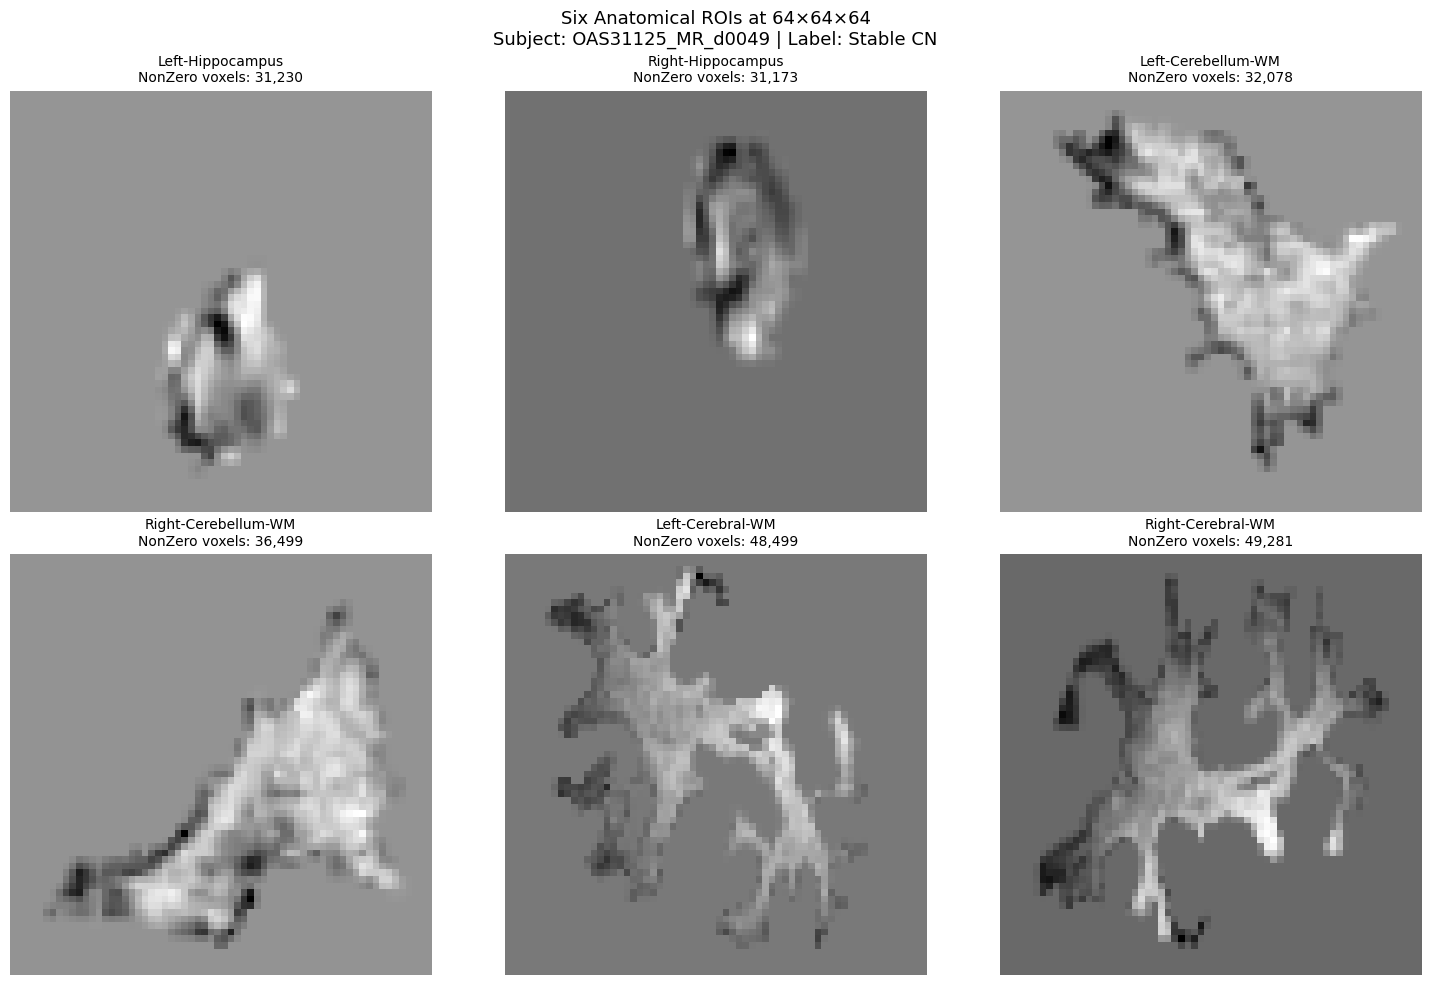

Saved to cache directory.


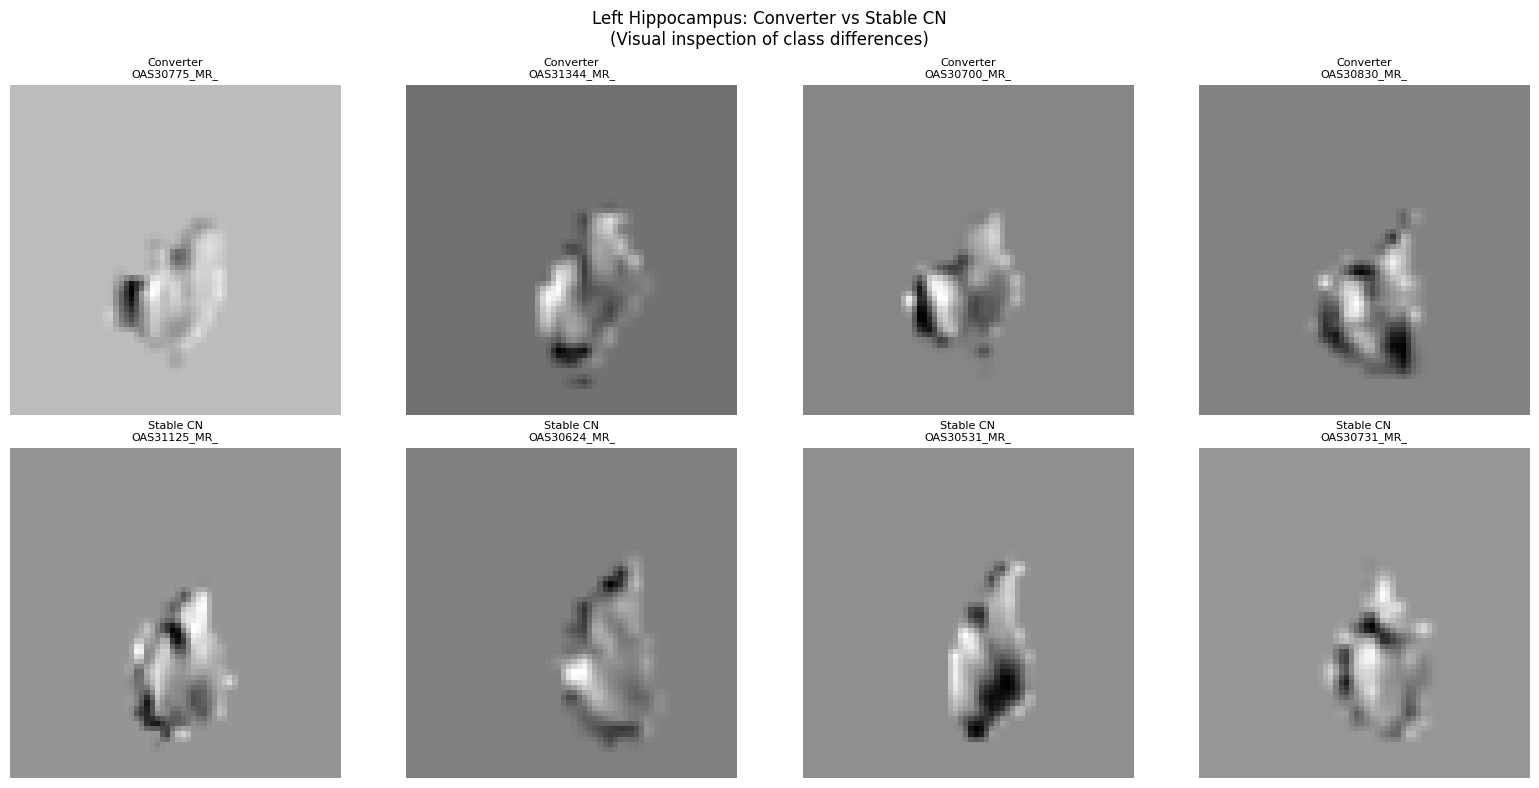

Saved to cache directory.


In [5]:
# =============================================================
# CELL 2.2 — ROI Visualisation
# Displays the 6 extracted ROIs for one subject to confirm
# anatomical structure is preserved after preprocessing
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, roi_name in enumerate(ROI_NAMES):
    ax  = axes[idx//3, idx%3]
    vol = test_rois[roi_name]
    mid = vol.shape[2] // 2
    ax.imshow(vol[:, :, mid], cmap='gray')
    nz  = (vol != 0).sum()
    ax.set_title(f'{roi_name}\nNonZero voxels: {nz:,}', fontsize=10)
    ax.axis('off')

plt.suptitle(
    f'Six Anatomical ROIs at 64×64×64\n'
    f'Subject: {X_val[0]} | Label: {"Converter" if y_val[0]==1 else "Stable CN"}',
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/roi_visualisation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to cache directory.")

# ── Compare hippocampus: converter vs stable CN ───────────────
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))

conv_indices = np.where(y_val == 1)[0][:4]
cn_indices   = np.where(y_val == 0)[0][:4]

for i in range(4):
    # Load from disk (preprocessing already tested above)
    conv_rois = extract_roi_cropped(X_val[conv_indices[i]])
    cn_rois   = extract_roi_cropped(X_val[cn_indices[i]])

    conv_vol = conv_rois['Left-Hippocampus']
    cn_vol   = cn_rois['Left-Hippocampus']

    axes2[0, i].imshow(conv_vol[:, :, 32], cmap='gray')
    axes2[0, i].set_title(f'Converter\n{X_val[conv_indices[i]][:12]}', fontsize=8)
    axes2[0, i].axis('off')

    axes2[1, i].imshow(cn_vol[:, :, 32], cmap='gray')
    axes2[1, i].set_title(f'Stable CN\n{X_val[cn_indices[i]][:12]}', fontsize=8)
    axes2[1, i].axis('off')

plt.suptitle('Left Hippocampus: Converter vs Stable CN\n(Visual inspection of class differences)', fontsize=12)
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/hippocampus_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to cache directory.")

In [6]:
# =============================================================
# CELL 2.3 — Cache All Subjects
# Preprocesses all 210 subjects and saves to disk as .npy files
# Shape per subject: (6, 64, 64, 64) — 6 ROIs × 64³
# Only needs to run once. Fast loading during training (~0.3s/batch)
# =============================================================

all_sessions = list(X_train) + list(X_val) + list(X_test)
failed = []

print(f"Caching {len(all_sessions)} subjects...")
print(f"Output shape per subject: (6, 64, 64, 64)")
print(f"Save location: {CACHE_DIR}\n")

for i, session_id in enumerate(all_sessions):
    save_path = f"{CACHE_DIR}/{session_id}_orig.npy"
    if os.path.exists(save_path):
        continue  # skip if already cached
    try:
        rois = extract_roi_cropped(session_id)
        roi_array = np.stack([rois[name] for name in ROI_NAMES], axis=0)
        np.save(save_path, roi_array)
        if (i+1) % 30 == 0:
            print(f"  [{i+1}/{len(all_sessions)}] done")
    except Exception as e:
        print(f"  FAILED {session_id}: {e}")
        failed.append(session_id)

print(f"\nCaching complete!")
print(f"  Successful: {len(all_sessions) - len(failed)}/{len(all_sessions)}")
print(f"  Failed:     {len(failed)}")

# ── Verify ────────────────────────────────────────────────────
sample = np.load(f"{CACHE_DIR}/{X_val[0]}_orig.npy")
print(f"\nSample verification:")
print(f"  Shape:   {sample.shape}")
print(f"  Mean:    {sample.mean():.4f}")
print(f"  NonZero: {(sample != 0).sum():,}")

Caching 210 subjects...
Output shape per subject: (6, 64, 64, 64)
Save location: D:/mamba_model/cache

  [30/210] done
  [60/210] done
  [90/210] done
  [120/210] done
  [150/210] done
  [180/210] done
  [210/210] done

Caching complete!
  Successful: 210/210
  Failed:     0

Sample verification:
  Shape:   (6, 64, 64, 64)
  Mean:    -0.0000
  NonZero: 228,760


In [8]:
# =============================================================
# CELL 3.1 — Augmentation Functions
# Creates 3 augmented copies of each training subject
# using random rotation and flips — expanding training set
# from 126 to 504 samples (4×), matching Jamie
#
# Seeds [1, 101, 42] match Vo et al. for reproducibility
# =============================================================

def augment_roi_array(roi_array, seed):
    """
    Apply consistent augmentation to all 6 ROIs simultaneously.
    Same random transformation applied to each ROI to preserve
    inter-ROI spatial relationships.

    Parameters
    ----------
    roi_array : np.array, shape (6, 64, 64, 64)
    seed      : int — random seed for reproducibility

    Returns
    -------
    augmented : np.array, shape (6, 64, 64, 64)
    """
    np.random.seed(seed)
    random.seed(seed)

    augmented = roi_array.copy()

    # Random rotation (±15 degrees)
    angle = np.random.uniform(-15, 15)
    for i in range(6):
        augmented[i] = rotate(
            augmented[i], angle,
            reshape=False, mode='constant', cval=0
        )

    # Random horizontal flip
    if np.random.random() > 0.5:
        augmented = augmented[:, ::-1, :, :].copy()

    # Random vertical flip
    if np.random.random() > 0.5:
        augmented = augmented[:, :, ::-1, :].copy()

    return augmented.astype(np.float32)


# ── Quick test ────────────────────────────────────────────────
sample_orig = np.load(f"{CACHE_DIR}/{X_train[0]}_orig.npy")
sample_aug  = augment_roi_array(sample_orig, seed=42)

print("Augmentation test:")
print(f"  Original shape: {sample_orig.shape}")
print(f"  Augmented shape: {sample_aug.shape}")
print(f"  Are they different: {not np.allclose(sample_orig, sample_aug)}")
print(f"  Mean difference: {np.abs(sample_orig - sample_aug).mean():.4f}")

Augmentation test:
  Original shape: (6, 64, 64, 64)
  Augmented shape: (6, 64, 64, 64)
  Are they different: True
  Mean difference: 0.1386


In [10]:
# =============================================================
# CELL 3.2 — Cache Augmented Training Data
# Creates 3 augmented versions of each training subject
# using seeds [1, 101, 42] matching Jamie
# Training set: 126 original + 378 augmented = 504 total
# Val/Test sets: original only (no augmentation)
# =============================================================

print("Creating augmented training data...")
print(f"Seeds: [1, 101, 42] — matching Jamie's")
print(f"Training subjects: {len(X_train)} × 4 = {len(X_train)*4} total\n")

failed_aug = []
for seed in [1, 101, 42]:
    for session_id in X_train:
        save_path = f"{CACHE_DIR}/{session_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{CACHE_DIR}/{session_id}_orig.npy")
            aug  = augment_roi_array(orig, seed=seed)
            np.save(save_path, aug)
        except Exception as e:
            print(f"  FAILED {session_id} seed {seed}: {e}")
            failed_aug.append((session_id, seed))
    print(f"  Seed {seed} complete ({len(X_train)} subjects)")

print(f"\nAugmentation complete!")
print(f"  Failed: {len(failed_aug)}")
print(f"  Total training files: {len(X_train) * 4} "
      f"({len(X_train)} orig + {len(X_train)*3} augmented)")

Creating augmented training data...
Seeds: [1, 101, 42] — matching Jamie's
Training subjects: 126 × 4 = 504 total

  Seed 1 complete (126 subjects)
  Seed 101 complete (126 subjects)
  Seed 42 complete (126 subjects)

Augmentation complete!
  Failed: 0
  Total training files: 504 (126 orig + 378 augmented)


In [11]:
# =============================================================
# CELL 3.3 — Dataset & DataLoader
# PyTorch Dataset that loads pre-cached ROI volumes.
# Training set loads original + 3 augmented versions (504 total)
# Val/Test sets load originals only (42 each)
# =============================================================

class ROIDataset(Dataset):
    """
    Loads pre-cached (6, 64, 64, 64) ROI arrays from disk.
    Training: original + 3 augmented versions per subject
    Val/Test: original only
    """
    def __init__(self, sessions, labels, cache_dir, is_train=False):
        self.cache_dir = cache_dir
        self.files     = []
        self.labels    = []

        if is_train:
            for session_id, label in zip(sessions, labels):
                # Original + 3 augmented
                for suffix in ['_orig', '_aug1', '_aug101', '_aug42']:
                    self.files.append(f"{cache_dir}/{session_id}{suffix}.npy")
                    self.labels.append(label)
        else:
            for session_id, label in zip(sessions, labels):
                self.files.append(f"{cache_dir}/{session_id}_orig.npy")
                self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        vol   = np.load(self.files[idx])
        label = self.labels[idx]
        return (
            torch.tensor(vol,   dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )


# ── Create datasets ───────────────────────────────────────────
train_dataset = ROIDataset(X_train, y_train, CACHE_DIR, is_train=True)
val_dataset   = ROIDataset(X_val,   y_val,   CACHE_DIR, is_train=False)
test_dataset  = ROIDataset(X_test,  y_test,  CACHE_DIR, is_train=False)

# ── Create dataloaders ────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=8,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8,
                          shuffle=False, num_workers=0)

# ── Verify ────────────────────────────────────────────────────
print(f"Dataset sizes:")
print(f"  Train: {len(train_dataset):>4} samples  "
      f"(126 subjects × 4 augmentations)")
print(f"  Val:   {len(val_dataset):>4} samples")
print(f"  Test:  {len(test_dataset):>4} samples")

batch_vols, batch_labels = next(iter(train_loader))
print(f"\nBatch shape: {batch_vols.shape}")
print(f"Labels:      {batch_labels.tolist()}")
print(f"\nDataloaders ready!")

Dataset sizes:
  Train:  504 samples  (126 subjects × 4 augmentations)
  Val:     42 samples
  Test:    42 samples

Batch shape: torch.Size([8, 6, 64, 64, 64])
Labels:      [0, 1, 1, 0, 0, 1, 0, 0]

Dataloaders ready!


In [12]:
# =============================================================
# CELL 4.1 — Mamba Block
# Implements a simplified Mamba State Space Model (SSM) block.
# Based on Gu & Dao (2023) "Mamba: Linear-Time Sequence
# Modeling with Selective State Spaces"
#
# Key components:
#   - LayerNorm + residual connection (stable training)
#   - Depthwise Conv1d (local context within sequence)
#   - SiLU gating (selective state space mechanism)
#   - Dropout regularisation
# =============================================================

class MambaBlock(nn.Module):
    """
    Mamba-inspired SSM block for processing token sequences.
    Operates on sequences of shape (batch, seq_len, d_model).
    """
    def __init__(self, d_model, d_state=16, expand=2):
        super().__init__()
        d_inner = d_model * expand

        self.norm    = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, d_inner * 2)
        self.conv1d  = nn.Conv1d(
            d_inner, d_inner,
            kernel_size=3, padding=1, groups=d_inner
        )
        self.act     = nn.SiLU()
        self.x_proj  = nn.Linear(d_inner, d_state + 1)
        self.dt_proj = nn.Linear(1, d_inner)
        self.out_proj= nn.Linear(d_inner, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        residual = x
        x = self.norm(x)

        # Split into two branches
        xz = self.in_proj(x)
        x_branch, z = xz.chunk(2, dim=-1)

        # Local context via depthwise convolution
        x_branch = self.conv1d(
            x_branch.transpose(1, 2)
        ).transpose(1, 2)
        x_branch = self.act(x_branch)

        # Selective state space parameters
        dB = self.x_proj(x_branch)
        dt, B = dB[..., :1], dB[..., 1:]
        dt = F.softplus(self.dt_proj(dt))

        # Gated SSM output
        y = x_branch * dt + x_branch * self.act(z)

        out = self.out_proj(y)
        out = self.dropout(out)
        return out + residual  # residual connection


# ── Verify ────────────────────────────────────────────────────
test_block  = MambaBlock(d_model=64).to(device)
test_input  = torch.randn(2, 6, 64).to(device)   # (batch, seq=6, d_model=64)
test_output = test_block(test_input)

print(f"MambaBlock verified:")
print(f"  Input:  {test_input.shape}  (batch, seq_len, d_model)")
print(f"  Output: {test_output.shape} (same shape — SSM preserves dimensions)")
params = sum(p.numel() for p in test_block.parameters())
print(f"  Parameters: {params:,}")

MambaBlock verified:
  Input:  torch.Size([2, 6, 64])  (batch, seq_len, d_model)
  Output: torch.Size([2, 6, 64]) (same shape — SSM preserves dimensions)
  Parameters: 27,985


In [13]:
# =============================================================
# CELL 4.2 — ROIEncoderMamba (Final Architecture)
# Novel ROI-guided Mamba architecture for CN→CI prediction.
#
# Pipeline:
#   1. Shared 3D CNN encoder extracts one feature vector per ROI
#   2. ROI identity embeddings distinguish which ROI each token is
#   3. Mamba SSM learns relationships BETWEEN the 6 ROI tokens
#   4. All 6 ROI features concatenated → classification head
#
# Design rationale:
#   - 6 tokens only → minimal overfitting risk on small dataset
#   - Shared CNN encoder → parameter efficiency
#   - ROI identity embeddings → Mamba knows which region it processes
#   - Mamba over 6 ROIs → learns inter-ROI dependencies
#     (e.g. does hippocampus + cerebral WM together predict conversion?)
# =============================================================

class ROIEncoderMamba(nn.Module):
    def __init__(self, n_rois=6, d_model=64, n_layers=2,
                 n_classes=2, dropout=0.3):
        super().__init__()
        self.n_rois   = n_rois
        self.d_model  = d_model

        # Shared CNN encoder — same weights applied to each ROI
        # Input:  (B, 1, 64, 64, 64)
        # Output: (B, d_model)
        self.roi_encoder = nn.Sequential(
            # (1, 64, 64, 64) → (16, 16, 16, 16)
            nn.Conv3d(1, 16, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.Dropout3d(0.2),
            # (16, 16, 16, 16) → (32, 8, 8, 8)
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Dropout3d(0.2),
            # (32, 8, 8, 8) → (d_model, 4, 4, 4)
            nn.Conv3d(32, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(d_model),
            nn.ReLU(),
            # Global average pool → (d_model,)
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )

        # ROI identity embedding — tells Mamba which ROI each token is
        # e.g. token 0 = Left Hippocampus, token 1 = Right Hippocampus
        self.roi_embed = nn.Embedding(n_rois, d_model)

        # Mamba blocks — process sequence of 6 ROI tokens
        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model, d_state=16, expand=2)
            for _ in range(n_layers)
        ])

        # Classification head
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model * n_rois, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (B, 6, 64, 64, 64)
        B, N, D, H, W = x.shape

        # Step 1: Encode each ROI independently with shared CNN
        roi_features = []
        for i in range(N):
            roi  = x[:, i:i+1, :, :, :]   # (B, 1, 64, 64, 64)
            feat = self.roi_encoder(roi)    # (B, d_model)
            roi_features.append(feat)

        # Step 2: Stack into sequence of 6 tokens
        tokens = torch.stack(roi_features, dim=1)  # (B, 6, d_model)

        # Step 3: Add ROI identity embeddings
        roi_ids = torch.arange(N, device=x.device)
        roi_emb = self.roi_embed(roi_ids)           # (6, d_model)
        tokens  = tokens + roi_emb.unsqueeze(0)     # (B, 6, d_model)

        # Step 4: Mamba processes 6 ROI tokens
        for layer in self.mamba_layers:
            tokens = layer(tokens)

        # Step 5: Classify from all 6 ROI features
        tokens = self.norm(tokens)
        tokens = tokens.view(B, -1)        # (B, 6 × d_model)
        return self.classifier(tokens)


# ── Build and verify ──────────────────────────────────────────
torch.manual_seed(42)
roi_mamba = ROIEncoderMamba(
    n_rois=6, d_model=64, n_layers=2,
    n_classes=2, dropout=0.3
).to(device)

total_params = sum(p.numel() for p in roi_mamba.parameters()
                   if p.requires_grad)
print(f"ROIEncoderMamba architecture:")
print(f"  Input:       (B, 6, 64, 64, 64) — 6 ROIs × 64³ volume")
print(f"  CNN output:  (B, 6, 64)          — 6 ROI feature vectors")
print(f"  Mamba input: (B, 6, 64)          — sequence of 6 tokens")
print(f"  Output:      (B, 2)              — converter vs stable CN")
print(f"  Parameters:  {total_params:,}")

with torch.no_grad():
    test_in  = torch.randn(2, 6, 64, 64, 64).to(device)
    test_out = roi_mamba(test_in)
    print(f"\nForward pass: {test_in.shape} → {test_out.shape} ")

ROIEncoderMamba architecture:
  Input:       (B, 6, 64, 64, 64) — 6 ROIs × 64³ volume
  CNN output:  (B, 6, 64)          — 6 ROI feature vectors
  Mamba input: (B, 6, 64)          — sequence of 6 tokens
  Output:      (B, 2)              — converter vs stable CN
  Parameters:  152,708

Forward pass: torch.Size([2, 6, 64, 64, 64]) → torch.Size([2, 2]) 


In [14]:
# =============================================================
# CELL 4.3 — FullBrainMamba (Ablation Baseline)
# Full brain Mamba model — no ROI selection.
# Used as ablation to quantify the contribution of
# anatomically-guided ROI selection vs processing the
# full masked brain volume.
#
# Input: single (1, 100, 100, 100) masked volume
#        (all 6 ROIs merged into one volume)
# Compare with ROIEncoderMamba to answer:
#   "Does separating ROIs into individual tokens help?"
# =============================================================

class FullBrainMamba(nn.Module):
    def __init__(self, d_model=64, n_layers=2,
                 n_classes=2, dropout=0.3):
        super().__init__()

        # CNN encoder — compresses full brain to single feature vector
        self.encoder = nn.Sequential(
            # (1, 100, 100, 100) → (16, 25, 25, 25)
            nn.Conv3d(1, 16, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.Dropout3d(0.2),
            # (16, 25, 25, 25) → (32, 13, 13, 13)
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Dropout3d(0.2),
            # (32, 13, 13, 13) → (d_model, 7, 7, 7)
            nn.Conv3d(32, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )

        # Single Mamba block on encoded feature
        self.mamba = MambaBlock(d_model, d_state=16, expand=2)
        self.norm  = nn.LayerNorm(d_model)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        # x: (B, 1, 100, 100, 100)
        feat = self.encoder(x)          # (B, d_model)
        feat = feat.unsqueeze(1)        # (B, 1, d_model) — seq of 1
        feat = self.mamba(feat)         # (B, 1, d_model)
        feat = self.norm(feat)
        feat = feat.squeeze(1)          # (B, d_model)
        return self.classifier(feat)


# ── Build and verify ──────────────────────────────────────────
torch.manual_seed(42)
full_brain_mamba = FullBrainMamba(
    d_model=64, n_layers=2,
    n_classes=2, dropout=0.3
).to(device)

total_params_fb = sum(p.numel() for p in full_brain_mamba.parameters()
                      if p.requires_grad)
print(f"FullBrainMamba architecture (ablation baseline):")
print(f"  Input:      (B, 1, 100, 100, 100) — full masked brain")
print(f"  Output:     (B, 2)                — converter vs stable CN")
print(f"  Parameters: {total_params_fb:,}")

with torch.no_grad():
    test_in  = torch.randn(2, 1, 100, 100, 100).to(device)
    test_out = full_brain_mamba(test_in)
    print(f"\nForward pass: {test_in.shape} → {test_out.shape} ✓")

print(f"\nParameter comparison:")
print(f"  ROIEncoderMamba:  152,708")
print(f"  FullBrainMamba:   {total_params_fb:,}")

FullBrainMamba architecture (ablation baseline):
  Input:      (B, 1, 100, 100, 100) — full masked brain
  Output:     (B, 2)                — converter vs stable CN
  Parameters: 101,715

Forward pass: torch.Size([2, 1, 100, 100, 100]) → torch.Size([2, 2]) ✓

Parameter comparison:
  ROIEncoderMamba:  152,708
  FullBrainMamba:   101,715


In [15]:
# =============================================================
# CELL 5.1 — Training & Evaluation Functions
# Standardised training and evaluation functions used for
# both ROIEncoderMamba and FullBrainMamba.
#
# Metrics match Jamie's:
#   - Accuracy
#   - True Positive Rate (Sensitivity) — correctly identified converters
#   - True Negative Rate (Specificity) — correctly identified stable CN
# =============================================================

def train_epoch(model, loader, optimizer, criterion, device):
    """One training epoch — forward pass, loss, backprop."""
    model.train()
    total_loss = 0
    for vols, labels in loader:
        vols, labels = vols.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(vols)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    """
    Evaluate model on a dataloader.
    Returns: avg_loss, accuracy, TPR (sensitivity), TNR (specificity)
    """
    model.eval()
    total_loss = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for vols, labels in loader:
            vols, labels = vols.to(device), labels.to(device)
            outputs      = model(vols)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item()
            preds        = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    tpr = recall_score(all_labels, all_preds)       # sensitivity
    tnr = specificity_score(all_labels, all_preds)  # specificity
    return avg_loss, acc, tpr, tnr


def run_experiment(model, train_loader, val_loader, test_loader,
                   save_path, device, patience=20, n_epochs=1000,
                   lr=0.0001, weight_decay=1e-4):
    """
    Full training loop with early stopping.
    Saves best model checkpoint based on validation loss.
    Returns test set results from best checkpoint.
    """
    # Class weights — account for slight class imbalance
    class_weights = torch.tensor(
        [504/244, 504/260], dtype=torch.float32
    ).to(device)
    criterion  = nn.CrossEntropyLoss(weight=class_weights)
    optimizer  = optim.Adam(model.parameters(),
                            lr=lr, weight_decay=weight_decay)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    best_val_loss  = float('inf')
    no_improvement = 0
    best_epoch     = 0

    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Val Acc':>8} | {'Val TPR':>8} | {'Val TNR':>8}")
    print("-" * 65)

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader,
                                 optimizer, criterion, device)
        val_loss, val_acc, val_tpr, val_tnr = evaluate(
            model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{val_acc:>8.4f} | {val_tpr:>8.4f} | {val_tnr:>8.4f}")

        if val_loss <= best_val_loss:
            best_val_loss  = val_loss
            no_improvement = 0
            best_epoch     = epoch
            torch.save(model.state_dict(), save_path,
                       _use_new_zipfile_serialization=True)
        else:
            no_improvement += 1
            if no_improvement > patience:
                print(f"\nEarly stopping at epoch {epoch}. "
                      f"Best epoch: {best_epoch}")
                break

    # Evaluate best checkpoint on test set
    model.load_state_dict(torch.load(save_path, weights_only=True))
    _, test_acc, test_tpr, test_tnr = evaluate(
        model, test_loader, criterion, device)
    return test_acc, test_tpr, test_tnr, best_epoch


print("Training functions defined.")
print("Metrics: Accuracy, TPR (Sensitivity), TNR (Specificity)")
print("Matching evaluation in Jamies")

Training functions defined.
Metrics: Accuracy, TPR (Sensitivity), TNR (Specificity)
Matching evaluation in Jamies


In [17]:
# =============================================================
# CELL 5.2 — ROIEncoderMamba — 5-Seed Evaluation
# Trains ROIEncoderMamba across 5 random seeds to obtain
# reliable mean ± std performance estimates.
# Multi-seed evaluation is standard practice for small datasets
# to account for initialisation sensitivity.
# =============================================================

results_roi = []

for seed in [42, 101, 1, 7, 123]:
    print(f"\n{'='*65}")
    print(f"ROIEncoderMamba — Seed {seed}")
    print('='*65)

    # Reset all random states for reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    # Fresh model for each seed
    model = ROIEncoderMamba(
        n_rois=6, d_model=64, n_layers=2,
        n_classes=2, dropout=0.3
    ).to(device)

    # Fresh dataloaders for each seed
    train_ds = ROIDataset(X_train, y_train, CACHE_DIR, is_train=True)
    val_ds   = ROIDataset(X_val,   y_val,   CACHE_DIR, is_train=False)
    test_ds  = ROIDataset(X_test,  y_test,  CACHE_DIR, is_train=False)

    train_ld = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
    val_ld   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)
    test_ld  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=0)

    save_path = f"{CKPT_DIR}/roi_mamba_seed{seed}.pth"

    test_acc, test_tpr, test_tnr, best_epoch = run_experiment(
        model, train_ld, val_ld, test_ld,
        save_path=save_path, device=device, patience=20
    )

    results_roi.append({
        'seed': seed, 'acc': test_acc,
        'tpr': test_tpr, 'tnr': test_tnr,
        'best_epoch': best_epoch
    })
    print(f"\nSeed {seed} TEST: Acc={test_acc*100:.1f}% | "
          f"TPR={test_tpr*100:.1f}% | TNR={test_tnr*100:.1f}%")

# ── Summary ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print("ROIEncoderMamba — SUMMARY")
print('='*65)
accs = [r['acc'] for r in results_roi]
tprs = [r['tpr'] for r in results_roi]
tnrs = [r['tnr'] for r in results_roi]

for r in results_roi:
    print(f"  Seed {r['seed']:>3}: Acc={r['acc']*100:.1f}% | "
          f"TPR={r['tpr']*100:.1f}% | TNR={r['tnr']*100:.1f}% | "
          f"Best epoch={r['best_epoch']}")

print(f"\n  Mean: Acc={np.mean(accs)*100:.1f}±{np.std(accs)*100:.1f}% | "
      f"TPR={np.mean(tprs)*100:.1f}±{np.std(tprs)*100:.1f}% | "
      f"TNR={np.mean(tnrs)*100:.1f}±{np.std(tnrs)*100:.1f}%")
print(f"  Best: Acc={max(accs)*100:.1f}%")


ROIEncoderMamba — Seed 42
Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
    1 |     0.7062 |     0.6972 |   0.5000 |   1.0000 |   0.0000
    2 |     0.6894 |     0.6903 |   0.5000 |   0.0000 |   1.0000
    3 |     0.6931 |     0.6901 |   0.5000 |   1.0000 |   0.0000
    4 |     0.6958 |     0.6852 |   0.6190 |   0.3333 |   0.9048
    5 |     0.6914 |     0.6828 |   0.6667 |   0.6190 |   0.7143
    6 |     0.6833 |     0.6814 |   0.6667 |   0.6667 |   0.6667
    7 |     0.6828 |     0.6816 |   0.5238 |   0.0952 |   0.9524
    8 |     0.6735 |     0.6770 |   0.5238 |   0.0952 |   0.9524
    9 |     0.6713 |     0.6734 |   0.6190 |   0.6667 |   0.5714
   10 |     0.6663 |     0.6690 |   0.5714 |   0.4286 |   0.7143
   11 |     0.6558 |     0.6682 |   0.5714 |   0.2857 |   0.8571
   12 |     0.6448 |     0.6738 |   0.5000 |   0.0000 |   1.0000
   13 |     0.6457 |     0.6561 |   0.5714 |   0.4762 |   0.66

In [19]:
# =============================================================
# CELL 6.1 — WholeBrain Dataset
# Loads the full skull-stripped orig.mgz volume (no ROI masking).
# Same augmentation as ROI model for fair comparison.
# =============================================================

class WholeBrainDataset(Dataset):
    """
    Loads full skull-stripped brain volumes from orig.mgz.
    NO ROI masking — whole brain used.
    Same augmentation strategy as ROIDataset for fair comparison.
    """
    def __init__(self, sessions, labels, fs_output, 
                 target_shape=(100, 100, 100), is_train=False):
        self.sessions     = sessions
        self.labels       = labels
        self.fs_output    = fs_output
        self.target_shape = target_shape
        self.is_train     = is_train

    def __len__(self):
        # Training: 4 versions per subject (orig + 3 augmented)
        return len(self.sessions) * 4 if self.is_train else len(self.sessions)

    def _load_and_preprocess(self, session_id, augment=False):
        orig_path = f"{self.fs_output}/{session_id}/mri/orig.mgz"
        vol = nib.load(orig_path).get_fdata().astype(np.float32)

        # Resize to target shape
        zoom_factors = [t / s for t, s in zip(self.target_shape, vol.shape)]
        vol = zoom(vol, zoom_factors, order=1)

        # Z-score normalise (whole brain, non-zero voxels)
        nz = vol[vol != 0]
        if len(nz) > 0 and nz.std() > 0:
            vol = np.where(vol != 0, (vol - nz.mean()) / nz.std(), 0)

        if augment:
            # Same augmentations as ROI model
            aug_seed = np.random.randint(0, 3)
            if aug_seed == 0:
                vol = np.flip(vol, axis=0).copy()
            elif aug_seed == 1:
                vol = np.flip(vol, axis=1).copy()
            else:
                angle = np.random.uniform(-10, 10)
                vol = rotate(vol, angle, axes=(0, 1), reshape=False)

        return vol

    def __getitem__(self, idx):
        if self.is_train:
            subj_idx = idx // 4
            aug_idx  = idx % 4
            session_id = self.sessions[subj_idx]
            label      = self.labels[subj_idx]
            vol = self._load_and_preprocess(session_id, augment=(aug_idx > 0))
        else:
            session_id = self.sessions[idx]
            label      = self.labels[idx]
            vol = self._load_and_preprocess(session_id, augment=False)

        vol_tensor = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)  # (1,D,H,W)
        return vol_tensor, torch.tensor(label, dtype=torch.long)


# ── Verify ────────────────────────────────────────────────────
wb_ds = WholeBrainDataset(X_val[:2], y_val[:2], FS_OUTPUT, is_train=False)
vol, lbl = wb_ds[0]
print(f"WholeBrainDataset verified:")
print(f"  Volume shape: {vol.shape}  (1, D, H, W)")
print(f"  Label: {lbl.item()}")
print(f"  Train size would be: {len(X_train) * 4} samples")
print(f"  Val/Test size: {len(X_val)} samples")

WholeBrainDataset verified:
  Volume shape: torch.Size([1, 100, 100, 100])  (1, D, H, W)
  Label: 0
  Train size would be: 504 samples
  Val/Test size: 42 samples


In [20]:
# =============================================================
# CELL 6.2 — WholeBrain DataLoaders
# =============================================================

wb_train_dataset = WholeBrainDataset(
    X_train, y_train, FS_OUTPUT,
    target_shape=(100, 100, 100), is_train=True
)
wb_val_dataset = WholeBrainDataset(
    X_val, y_val, FS_OUTPUT,
    target_shape=(100, 100, 100), is_train=False
)
wb_test_dataset = WholeBrainDataset(
    X_test, y_test, FS_OUTPUT,
    target_shape=(100, 100, 100), is_train=False
)

wb_train_loader = DataLoader(wb_train_dataset, batch_size=4,
                              shuffle=True, num_workers=0)
wb_val_loader   = DataLoader(wb_val_dataset,   batch_size=4,
                              shuffle=False, num_workers=0)
wb_test_loader  = DataLoader(wb_test_dataset,  batch_size=4,
                              shuffle=False, num_workers=0)

batch_vols, batch_labels = next(iter(wb_train_loader))
print(f"WholeBrain batch shape: {batch_vols.shape}")  # (4, 1, 100, 100, 100)
print(f"Labels: {batch_labels.tolist()}")

WholeBrain batch shape: torch.Size([4, 1, 100, 100, 100])
Labels: [1, 0, 0, 0]


In [24]:
# =============================================================
# CELL A — ROIEncoderMamba v2 Definition
# Changes from v1: d_model 64→32, n_layers 2→1,
# dropout 0.2→0.3 (encoder), 0.3→0.5 (classifier)
# =============================================================

class ROIEncoderMamba_v2(nn.Module):
    def __init__(self, n_rois=6, d_model=32, n_layers=1,
                 n_classes=2, dropout=0.5):
        super().__init__()
        self.n_rois  = n_rois
        self.d_model = d_model

        self.roi_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.Dropout3d(0.3),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Dropout3d(0.3),
            nn.Conv3d(32, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm3d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )

        self.roi_embed = nn.Embedding(n_rois, d_model)

        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model, d_state=16, expand=2)
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model * n_rois, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        B, N, D, H, W = x.shape

        roi_features = []
        for i in range(N):
            roi  = x[:, i:i+1, :, :, :]
            feat = self.roi_encoder(roi)
            roi_features.append(feat)

        tokens = torch.stack(roi_features, dim=1)

        roi_ids = torch.arange(N, device=x.device)
        roi_emb = self.roi_embed(roi_ids)
        tokens  = tokens + roi_emb.unsqueeze(0)

        for layer in self.mamba_layers:
            tokens = layer(tokens)

        tokens = self.norm(tokens)
        tokens = tokens.view(B, -1)
        return self.classifier(tokens)


# ── Verify ────────────────────────────────────────────────────
torch.manual_seed(42)
test_v2 = ROIEncoderMamba_v2().to(device)
total_params_v2 = sum(p.numel() for p in test_v2.parameters()
                      if p.requires_grad)
print(f"ROIEncoderMamba v2:")
print(f"  d_model:    32  (was 64)")
print(f"  n_layers:   1   (was 2)")
print(f"  dropout:    0.5 (was 0.3)")
print(f"  Parameters: {total_params_v2:,}  (was 152,708)")

with torch.no_grad():
    test_in  = torch.randn(2, 6, 64, 64, 64).to(device)
    test_out = test_v2(test_in)
    print(f"  Forward:    {test_in.shape} → {test_out.shape} ✓")

ROIEncoderMamba v2:
  d_model:    32  (was 64)
  n_layers:   1   (was 2)
  dropout:    0.5 (was 0.3)
  Parameters: 64,307  (was 152,708)
  Forward:    torch.Size([2, 6, 64, 64, 64]) → torch.Size([2, 2]) ✓


In [25]:
# =============================================================
# CELL B — ROIEncoderMamba v2 — 5-Seed Training
# Uses existing ROI cache — no preprocessing needed
# =============================================================

results_v2 = []

print("=" * 65)
print("ROIEncoderMamba v2 — 5-Seed Run")
print("=" * 65)

for seed in [42, 101, 1, 7, 123]:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    model = ROIEncoderMamba_v2(
        n_rois=6, d_model=32, n_layers=1,
        n_classes=2, dropout=0.5
    ).to(device)

    # Same ROI cache as v1 — loads instantly
    train_dataset = ROIDataset(X_train, y_train, CACHE_DIR, is_train=True)
    val_dataset   = ROIDataset(X_val,   y_val,   CACHE_DIR, is_train=False)
    test_dataset  = ROIDataset(X_test,  y_test,  CACHE_DIR, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=8,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=8,
                              shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=8,
                              shuffle=False, num_workers=0)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10)

    best_val_loss  = float('inf')
    no_improvement = 0
    best_epoch     = 0
    save_path      = f"{CKPT_DIR}/roi_mamba_v2_seed{seed}.pt"

    print(f"\n{'='*65}")
    print(f"ROIEncoderMamba v2 — Seed {seed}")
    print(f"{'='*65}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Val Acc':>8} | {'Val TPR':>8} | {'Val TNR':>8}")
    print("-" * 65)

    for epoch in range(1, 101):
        train_loss = train_epoch(model, train_loader, optimizer,
                                 criterion, device)
        val_loss, val_acc, val_tpr, val_tnr = evaluate(
            model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{val_acc:>8.4f} | {val_tpr:>8.4f} | {val_tnr:>8.4f}")

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_epoch     = epoch
            no_improvement = 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improvement += 1
            if no_improvement >= 20:
                print(f"\nEarly stopping at epoch {epoch}. "
                      f"Best epoch: {best_epoch}")
                break

    model.load_state_dict(torch.load(save_path))
    _, test_acc, test_tpr, test_tnr = evaluate(
        model, test_loader, criterion, device)

    print(f"\nSeed {seed} TEST: "
          f"Acc={test_acc*100:.1f}% | "
          f"TPR={test_tpr*100:.1f}% | "
          f"TNR={test_tnr*100:.1f}%")

    results_v2.append({
        'seed': seed, 'acc': test_acc,
        'tpr': test_tpr, 'tnr': test_tnr,
        'best_epoch': best_epoch
    })

print(f"\n{'='*65}")
print("ROIEncoderMamba v2 — SUMMARY")
print(f"{'='*65}")
for r in results_v2:
    print(f"  Seed {r['seed']:>3}: "
          f"Acc={r['acc']*100:.1f}% | "
          f"TPR={r['tpr']*100:.1f}% | "
          f"TNR={r['tnr']*100:.1f}% | "
          f"Best epoch={r['best_epoch']}")
accs_v2 = [r['acc'] for r in results_v2]
tprs_v2 = [r['tpr'] for r in results_v2]
tnrs_v2 = [r['tnr'] for r in results_v2]
print(f"\n  Mean: Acc={np.mean(accs_v2)*100:.1f}±{np.std(accs_v2)*100:.1f}% | "
      f"TPR={np.mean(tprs_v2)*100:.1f}±{np.std(tprs_v2)*100:.1f}% | "
      f"TNR={np.mean(tnrs_v2)*100:.1f}±{np.std(tnrs_v2)*100:.1f}%")
print(f"  Best: Acc={max(accs_v2)*100:.1f}%")

ROIEncoderMamba v2 — 5-Seed Run

ROIEncoderMamba v2 — Seed 42
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7014 |     0.6934 |   0.5476 |   0.2857 |   0.8095
     2 |     0.6981 |     0.6936 |   0.5000 |   1.0000 |   0.0000
     3 |     0.6940 |     0.6924 |   0.5000 |   1.0000 |   0.0000
     4 |     0.7043 |     0.6910 |   0.5000 |   1.0000 |   0.0000
     5 |     0.6892 |     0.6893 |   0.5000 |   1.0000 |   0.0000
     6 |     0.6907 |     0.6875 |   0.6429 |   0.4286 |   0.8571
     7 |     0.6846 |     0.6892 |   0.5238 |   0.0952 |   0.9524
     8 |     0.6871 |     0.6856 |   0.4762 |   0.9048 |   0.0476
     9 |     0.6824 |     0.6836 |   0.6667 |   0.6667 |   0.6667
    10 |     0.6860 |     0.6812 |   0.5714 |   0.9048 |   0.2381
    11 |     0.6774 |     0.6802 |   0.6190 |   0.2857 |   0.9524
    12 |     0.6797 |     0.6801 |   0.4762 |   0.9524 |   0.0000
    13 |     0

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\86664349.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 42 TEST: Acc=71.4% | TPR=61.9% | TNR=81.0%

ROIEncoderMamba v2 — Seed 101
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7055 |     0.6927 |   0.5000 |   1.0000 |   0.0000
     2 |     0.7114 |     0.6918 |   0.5000 |   1.0000 |   0.0000
     3 |     0.6989 |     0.6915 |   0.5000 |   1.0000 |   0.0000
     4 |     0.6998 |     0.6895 |   0.5238 |   0.9524 |   0.0952
     5 |     0.6955 |     0.6888 |   0.4762 |   0.9524 |   0.0000
     6 |     0.6906 |     0.6902 |   0.5000 |   1.0000 |   0.0000
     7 |     0.6916 |     0.6893 |   0.5000 |   1.0000 |   0.0000
     8 |     0.6907 |     0.6892 |   0.5000 |   1.0000 |   0.0000
     9 |     0.6927 |     0.6893 |   0.5000 |   1.0000 |   0.0000
    10 |     0.6918 |     0.6870 |   0.5714 |   0.7143 |   0.4286
    11 |     0.6883 |     0.6874 |   0.5000 |   1.0000 |   0.0000
    12 |     0.6803 |     0.6856 |   0.5000 |   1.0000 |   0.0

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\86664349.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 101 TEST: Acc=57.1% | TPR=76.2% | TNR=38.1%

ROIEncoderMamba v2 — Seed 1
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7048 |     0.6924 |   0.5000 |   1.0000 |   0.0000
     2 |     0.7044 |     0.6910 |   0.5000 |   1.0000 |   0.0000
     3 |     0.6914 |     0.6905 |   0.5000 |   1.0000 |   0.0000
     4 |     0.6985 |     0.6913 |   0.5000 |   1.0000 |   0.0000
     5 |     0.6978 |     0.6896 |   0.5000 |   1.0000 |   0.0000
     6 |     0.6918 |     0.6903 |   0.5000 |   1.0000 |   0.0000
     7 |     0.6937 |     0.6881 |   0.5714 |   1.0000 |   0.1429
     8 |     0.6905 |     0.6883 |   0.5000 |   1.0000 |   0.0000
     9 |     0.6899 |     0.6871 |   0.5476 |   1.0000 |   0.0952
    10 |     0.6898 |     0.6863 |   0.5714 |   1.0000 |   0.1429
    11 |     0.6898 |     0.6869 |   0.5000 |   1.0000 |   0.0000
    12 |     0.6897 |     0.6869 |   0.5000 |   1.0000 |   0.00

...


ROIEncoderMamba v2 — Seed 7
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7006 |     0.6963 |   0.5000 |   1.0000 |   0.0000
     2 |     0.7055 |     0.6954 |   0.5000 |   1.0000 |   0.0000
     3 |     0.6944 |     0.6949 |   0.5000 |   1.0000 |   0.0000
     4 |     0.7038 |     0.6928 |   0.5000 |   1.0000 |   0.0000
     5 |     0.6939 |     0.6916 |   0.5000 |   1.0000 |   0.0000
     6 |     0.6888 |     0.6905 |   0.5000 |   1.0000 |   0.0000
     7 |     0.6946 |     0.6900 |   0.5000 |   1.0000 |   0.0000
     8 |     0.6916 |     0.6889 |   0.5000 |   1.0000 |   0.0000
     9 |     0.6881 |     0.6877 |   0.5000 |   0.9048 |   0.0952
    10 |     0.6900 |     0.6882 |   0.5000 |   1.0000 |   0.0000
    11 |     0.6836 |     0.6898 |   0.5000 |   1.0000 |   0.0000
    12 |     0.6824 |     0.6843 |   0.5238 |   0.9048 |   0.1429
    13 |     0.6868 |     0.6835 |   0.5476 |  

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\86664349.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 7 TEST: Acc=71.4% | TPR=81.0% | TNR=61.9%

ROIEncoderMamba v2 — Seed 123
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7268 |     0.6908 |   0.5000 |   1.0000 |   0.0000
     2 |     0.7044 |     0.6898 |   0.5000 |   1.0000 |   0.0000
     3 |     0.6895 |     0.6880 |   0.5000 |   1.0000 |   0.0000
     4 |     0.7014 |     0.6891 |   0.5000 |   1.0000 |   0.0000
     5 |     0.6917 |     0.6857 |   0.5000 |   1.0000 |   0.0000
     6 |     0.6839 |     0.6838 |   0.5000 |   1.0000 |   0.0000
     7 |     0.6864 |     0.6820 |   0.6667 |   0.6190 |   0.7143
     8 |     0.6923 |     0.6818 |   0.5000 |   1.0000 |   0.0000
     9 |     0.6851 |     0.6789 |   0.6905 |   0.7619 |   0.6190
    10 |     0.6848 |     0.6792 |   0.5714 |   1.0000 |   0.1429
    11 |     0.6859 |     0.6753 |   0.6190 |   0.2857 |   0.9524
    12 |     0.6792 |     0.6764 |   0.5000 |   1.0000 |   0.00

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\86664349.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 123 TEST: Acc=66.7% | TPR=81.0% | TNR=52.4%

ROIEncoderMamba v2 — SUMMARY
  Seed  42: Acc=71.4% | TPR=61.9% | TNR=81.0% | Best epoch=24
  Seed 101: Acc=57.1% | TPR=76.2% | TNR=38.1% | Best epoch=27
  Seed   1: Acc=61.9% | TPR=76.2% | TNR=47.6% | Best epoch=30
  Seed   7: Acc=71.4% | TPR=81.0% | TNR=61.9% | Best epoch=31
  Seed 123: Acc=66.7% | TPR=81.0% | TNR=52.4% | Best epoch=25

  Mean: Acc=65.7±5.6% | TPR=75.2±7.0% | TNR=56.2±14.6%
  Best: Acc=71.4%


In [29]:
# =============================================================
# CELL C — Cache Whole Brain Volumes + Dataset
# =============================================================

CACHE_DIR_FB = "D:/mamba_model/cache_fullbrain"
os.makedirs(CACHE_DIR_FB, exist_ok=True)

TARGET_SHAPE_FB = (100, 100, 100)

def preprocess_wholebrain(session_id):
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"
    vol = nib.load(orig_path).get_fdata().astype(np.float32)

    zoom_factors = [t / s for t, s in zip(TARGET_SHAPE_FB, vol.shape)]
    vol = zoom(vol, zoom_factors, order=1)

    nz = vol[vol != 0]
    if len(nz) > 0 and nz.std() > 0:
        vol = np.where(vol != 0, (vol - nz.mean()) / nz.std(), 0.0)

    return vol

def augment_wholebrain(vol, aug_id):
    if aug_id == 1:
        return np.flip(vol, axis=0).copy()
    elif aug_id == 2:
        return np.flip(vol, axis=1).copy()
    else:
        angle = np.random.uniform(-10, 10)
        return rotate(vol, angle, axes=(0, 1), reshape=False).copy()

print("Caching whole brain volumes...")

train_set = set(X_train)

for i, session_id in enumerate(sessions):
    orig_file = f"{session_id}_orig.npy"
    orig_path = os.path.join(CACHE_DIR_FB, orig_file)

    if not os.path.exists(orig_path):
        vol = preprocess_wholebrain(session_id)
        np.save(orig_path, vol)

    if session_id in train_set:
        for aug_id in [1, 2, 3]:
            aug_file = f"{session_id}_aug{aug_id}.npy"
            aug_path = os.path.join(CACHE_DIR_FB, aug_file)

            if not os.path.exists(aug_path):
                vol = preprocess_wholebrain(session_id)
                aug = augment_wholebrain(vol, aug_id)
                np.save(aug_path, aug)

    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(sessions)} subjects done")

print(f"\nDone. {len(os.listdir(CACHE_DIR_FB))} files cached.")


class FullBrainDataset(Dataset):
    def __init__(self, session_ids, labels, cache_dir, is_train=False):
        self.samples = []
        self.cache_dir = cache_dir

        for session_id, label in zip(session_ids, labels):
            self.samples.append((session_id, label, "orig"))

            if is_train:
                for aug_id in [1, 2, 3]:
                    self.samples.append((session_id, label, f"aug{aug_id}"))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        session_id, label, version = self.samples[idx]

        path = os.path.join(self.cache_dir, f"{session_id}_{version}.npy")
        vol = np.load(path).astype(np.float32)

        vol = torch.tensor(vol).unsqueeze(0)  # (1, 100, 100, 100)
        label = torch.tensor(label).long()

        return vol, label

Caching whole brain volumes...
  20/210 subjects done
  40/210 subjects done
  60/210 subjects done
  80/210 subjects done
  100/210 subjects done
  120/210 subjects done
  140/210 subjects done
  160/210 subjects done
  180/210 subjects done
  200/210 subjects done

Done. 588 files cached.


In [30]:
# =============================================================
# CELL D — FullBrainMamba — 5-Seed Training
# Uses existing FullBrainMamba from Cell 4.3 unchanged
# Same hyperparameters as v2 ROI run for fair comparison
# =============================================================

results_fb = []

print("=" * 65)
print("FullBrainMamba — 5-Seed Run")
print("=" * 65)

for seed in [42, 101, 1, 7, 123]:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    model_fb = FullBrainMamba(
        d_model=64, n_layers=2,
        n_classes=2, dropout=0.3
    ).to(device)

    train_dataset_fb = FullBrainDataset(
        X_train, y_train, CACHE_DIR_FB, is_train=True)
    val_dataset_fb   = FullBrainDataset(
        X_val,   y_val,   CACHE_DIR_FB, is_train=False)
    test_dataset_fb  = FullBrainDataset(
        X_test,  y_test,  CACHE_DIR_FB, is_train=False)

    train_loader_fb = DataLoader(train_dataset_fb, batch_size=4,
                                 shuffle=True,  num_workers=0)
    val_loader_fb   = DataLoader(val_dataset_fb,   batch_size=4,
                                 shuffle=False, num_workers=0)
    test_loader_fb  = DataLoader(test_dataset_fb,  batch_size=4,
                                 shuffle=False, num_workers=0)

    criterion_fb = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_fb = optim.AdamW(model_fb.parameters(),
                               lr=1e-4, weight_decay=1e-3)
    scheduler_fb = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fb, mode='min', factor=0.5, patience=10)

    best_val_loss  = float('inf')
    no_improvement = 0
    best_epoch     = 0
    save_path_fb   = f"{CKPT_DIR}/fullbrain_mamba_v2_seed{seed}.pt"

    print(f"\n{'='*65}")
    print(f"FullBrainMamba — Seed {seed}")
    print(f"{'='*65}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Val Acc':>8} | {'Val TPR':>8} | {'Val TNR':>8}")
    print("-" * 65)

    for epoch in range(1, 101):
        train_loss = train_epoch(model_fb, train_loader_fb,
                                 optimizer_fb, criterion_fb, device)
        val_loss, val_acc, val_tpr, val_tnr = evaluate(
            model_fb, val_loader_fb, criterion_fb, device)
        scheduler_fb.step(val_loss)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{val_acc:>8.4f} | {val_tpr:>8.4f} | {val_tnr:>8.4f}")

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_epoch     = epoch
            no_improvement = 0
            torch.save(model_fb.state_dict(), save_path_fb)
        else:
            no_improvement += 1
            if no_improvement >= 20:
                print(f"\nEarly stopping at epoch {epoch}. "
                      f"Best epoch: {best_epoch}")
                break

    model_fb.load_state_dict(torch.load(save_path_fb))
    _, test_acc, test_tpr, test_tnr = evaluate(
        model_fb, test_loader_fb, criterion_fb, device)

    print(f"\nSeed {seed} TEST: "
          f"Acc={test_acc*100:.1f}% | "
          f"TPR={test_tpr*100:.1f}% | "
          f"TNR={test_tnr*100:.1f}%")

    results_fb.append({
        'seed': seed, 'acc': test_acc,
        'tpr': test_tpr, 'tnr': test_tnr,
        'best_epoch': best_epoch
    })

print(f"\n{'='*65}")
print("FullBrainMamba — SUMMARY")
print(f"{'='*65}")
for r in results_fb:
    print(f"  Seed {r['seed']:>3}: "
          f"Acc={r['acc']*100:.1f}% | "
          f"TPR={r['tpr']*100:.1f}% | "
          f"TNR={r['tnr']*100:.1f}% | "
          f"Best epoch={r['best_epoch']}")
accs_fb = [r['acc'] for r in results_fb]
tprs_fb = [r['tpr'] for r in results_fb]
tnrs_fb = [r['tnr'] for r in results_fb]
print(f"\n  Mean: Acc={np.mean(accs_fb)*100:.1f}±{np.std(accs_fb)*100:.1f}% | "
      f"TPR={np.mean(tprs_fb)*100:.1f}±{np.std(tprs_fb)*100:.1f}% | "
      f"TNR={np.mean(tnrs_fb)*100:.1f}±{np.std(tnrs_fb)*100:.1f}%")
print(f"  Best: Acc={max(accs_fb)*100:.1f}%")

FullBrainMamba — 5-Seed Run

FullBrainMamba — Seed 42
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7182 |     0.6896 |   0.5476 |   0.9048 |   0.1905
     2 |     0.7037 |     0.7152 |   0.5000 |   1.0000 |   0.0000
     3 |     0.7044 |     0.6817 |   0.5476 |   0.6190 |   0.4762
     4 |     0.6907 |     0.6976 |   0.5000 |   0.9524 |   0.0476
     5 |     0.7006 |     0.6765 |   0.6429 |   0.4762 |   0.8095
     6 |     0.6938 |     0.6817 |   0.5952 |   0.3810 |   0.8095
     7 |     0.6902 |     0.6815 |   0.5238 |   0.8095 |   0.2381
     8 |     0.6895 |     0.6744 |   0.5238 |   0.6667 |   0.3810
     9 |     0.6898 |     0.6710 |   0.5952 |   0.8095 |   0.3810
    10 |     0.6821 |     0.6716 |   0.6190 |   0.4286 |   0.8095
    11 |     0.6860 |     0.6655 |   0.6190 |   0.3810 |   0.8571
    12 |     0.6745 |     0.6729 |   0.6190 |   0.9048 |   0.3333
    13 |     0.6909 | 

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\3581651524.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fb.load_state_dict(torch.load(save_path_fb))



Seed 42 TEST: Acc=64.3% | TPR=57.1% | TNR=71.4%

FullBrainMamba — Seed 101
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7034 |     0.7094 |   0.4762 |   0.9524 |   0.0000
     2 |     0.6977 |     0.6910 |   0.5714 |   0.3333 |   0.8095
     3 |     0.6968 |     0.6873 |   0.5476 |   0.9524 |   0.1429
     4 |     0.6968 |     0.6791 |   0.6905 |   0.6190 |   0.7619
     5 |     0.6829 |     0.6833 |   0.5238 |   0.3810 |   0.6667
     6 |     0.6911 |     0.6866 |   0.5714 |   0.1905 |   0.9524
     7 |     0.6907 |     0.6738 |   0.5952 |   0.2381 |   0.9524
     8 |     0.6915 |     0.6696 |   0.5952 |   0.2381 |   0.9524
     9 |     0.6908 |     0.6709 |   0.6190 |   0.2857 |   0.9524
    10 |     0.6953 |     0.6729 |   0.5476 |   0.3333 |   0.7619
    11 |     0.6867 |     0.6754 |   0.6190 |   0.2857 |   0.9524
    12 |     0.6908 |     0.6675 |   0.6190 |   0.2857 |   0.9524


C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\3581651524.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fb.load_state_dict(torch.load(save_path_fb))



Seed 101 TEST: Acc=69.0% | TPR=61.9% | TNR=76.2%

FullBrainMamba — Seed 1
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.6970 |     0.6826 |   0.5714 |   0.5714 |   0.5714
     2 |     0.6949 |     0.6860 |   0.5714 |   0.6190 |   0.5238
     3 |     0.6944 |     0.6806 |   0.5238 |   0.0952 |   0.9524
     4 |     0.7058 |     0.6851 |   0.6429 |   0.4762 |   0.8095
     5 |     0.6945 |     0.6794 |   0.5476 |   0.1429 |   0.9524
     6 |     0.6964 |     0.6810 |   0.6190 |   0.2381 |   1.0000
     7 |     0.6928 |     0.6778 |   0.6429 |   0.3333 |   0.9524
     8 |     0.6934 |     0.6775 |   0.5714 |   0.1429 |   1.0000
     9 |     0.7031 |     0.6767 |   0.5952 |   0.1905 |   1.0000
    10 |     0.6899 |     0.6772 |   0.5952 |   0.3810 |   0.8095
    11 |     0.6920 |     0.6809 |   0.5476 |   0.6667 |   0.4286
    12 |     0.6889 |     0.6768 |   0.5952 |   0.2381 |   0.9524
 

...

     1 |     0.7038 |     0.6814 |   0.5476 |   0.1905 |   0.9048
     2 |     0.6974 |     0.6845 |   0.5714 |   0.8095 |   0.3333
     3 |     0.6969 |     0.6806 |   0.6429 |   0.7143 |   0.5714
     4 |     0.6940 |     0.6804 |   0.5952 |   0.2857 |   0.9048
     5 |     0.6969 |     0.6968 |   0.5238 |   0.0476 |   1.0000
     6 |     0.6921 |     0.6777 |   0.5714 |   0.1429 |   1.0000
     7 |     0.6956 |     0.6781 |   0.5476 |   0.1429 |   0.9524
     8 |     0.6773 |     0.6746 |   0.5238 |   0.4762 |   0.5714
     9 |     0.6892 |     0.6678 |   0.5476 |   0.4286 |   0.6667
    10 |     0.6866 |     0.6631 |   0.5714 |   0.7619 |   0.3810
    11 |     0.6938 |     0.6631 |   0.5476 |   0.3810 |   0.7143
    12 |     0.6881 |     0.6651 |   0.5476 |   0.2381 |   0.8571
    13 |     0.6888 |     0.6627 |   0.5952 |   0.5238 |   0.6667
    14 |     0.6881 |     0.6598 |   0.5952 |   0.3333 |   0.8571
    15 |     0.6815 |     0.6576 |   0.5714 |   0.2381 |   0.9048
    16 |  

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\3581651524.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fb.load_state_dict(torch.load(save_path_fb))


     1 |     0.7077 |     0.6826 |   0.6667 |   0.7619 |   0.5714
     2 |     0.7022 |     0.6864 |   0.5714 |   0.1905 |   0.9524
     3 |     0.6984 |     0.6878 |   0.5476 |   0.1429 |   0.9524
     4 |     0.6916 |     0.6739 |   0.5714 |   0.9048 |   0.2381
     5 |     0.6886 |     0.6732 |   0.5476 |   0.1429 |   0.9524
     6 |     0.6972 |     0.6688 |   0.6190 |   0.3333 |   0.9048
     7 |     0.6887 |     0.6714 |   0.5714 |   0.1429 |   1.0000
     8 |     0.6832 |     0.6599 |   0.6667 |   0.6667 |   0.6667
     9 |     0.7010 |     0.6661 |   0.5714 |   0.2857 |   0.8571
    10 |     0.6850 |     0.6600 |   0.5952 |   0.2381 |   0.9524
    11 |     0.6857 |     0.6548 |   0.6190 |   0.2857 |   0.9524
    12 |     0.6766 |     0.6552 |   0.5952 |   0.2381 |   0.9524
    13 |     0.6802 |     0.6497 |   0.5952 |   0.2857 |   0.9048
    14 |     0.6909 |     0.6554 |   0.6190 |   0.4762 |   0.7619
    15 |     0.6766 |     0.6546 |   0.5952 |   0.2857 |   0.9048
    16 |  

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\3581651524.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fb.load_state_dict(torch.load(save_path_fb))



Seed 123 TEST: Acc=61.9% | TPR=33.3% | TNR=90.5%

FullBrainMamba — SUMMARY
  Seed  42: Acc=64.3% | TPR=57.1% | TNR=71.4% | Best epoch=29
  Seed 101: Acc=69.0% | TPR=61.9% | TNR=76.2% | Best epoch=34
  Seed   1: Acc=54.8% | TPR=14.3% | TNR=95.2% | Best epoch=33
  Seed   7: Acc=61.9% | TPR=57.1% | TNR=66.7% | Best epoch=35
  Seed 123: Acc=61.9% | TPR=33.3% | TNR=90.5% | Best epoch=34

  Mean: Acc=62.4±4.6% | TPR=44.8±18.2% | TNR=80.0±11.0%
  Best: Acc=69.0%


In [31]:
# =============================================================
# CELL E — Final Comparison Table
# Fill in results_v1 from your earlier run
# =============================================================

# From your original run (already completed)
results_v1 = [
    {'seed':  42, 'acc': 0.690, 'tpr': 0.571, 'tnr': 0.810},
    {'seed': 101, 'acc': 0.690, 'tpr': 0.762, 'tnr': 0.619},
    {'seed':   1, 'acc': 0.619, 'tpr': 0.619, 'tnr': 0.619},
    {'seed':   7, 'acc': 0.619, 'tpr': 0.619, 'tnr': 0.619},
    {'seed': 123, 'acc': 0.643, 'tpr': 0.571, 'tnr': 0.714},
]
accs_v1 = [r['acc'] for r in results_v1]
tprs_v1 = [r['tpr'] for r in results_v1]
tnrs_v1 = [r['tnr'] for r in results_v1]

# Literature baselines (Vo et al.)
jamie_voxel   = {'acc': 0.610, 'tpr': 0.762, 'tnr': 0.450}
jamie_patches = {'acc': 0.683, 'tpr': 0.810, 'tnr': 0.550}

W = 73
print("=" * W)
print("FINAL COMPARISON — CN→CI Conversion Prediction (OASIS-3, n=210)")
print("=" * W)
print(f"{'Model':<35} | {'Acc (%)':>9} | {'TPR (%)':>9} | {'TNR (%)':>9}")
print("-" * W)
print(f"{'Vo et al. — MRI voxel':<35} | "
      f"{jamie_voxel['acc']*100:>8.1f}% | "
      f"{jamie_voxel['tpr']*100:>8.1f}% | "
      f"{jamie_voxel['tnr']*100:>8.1f}%")
print(f"{'Vo et al. — MRI patches':<35} | "
      f"{jamie_patches['acc']*100:>8.1f}% | "
      f"{jamie_patches['tpr']*100:>8.1f}% | "
      f"{jamie_patches['tnr']*100:>8.1f}%")
print("-" * W)
print(f"{'FullBrainMamba (ablation)':<35} | "
      f"{np.mean(accs_fb)*100:>7.1f}±{np.std(accs_fb)*100:.1f}% | "
      f"{np.mean(tprs_fb)*100:>7.1f}±{np.std(tprs_fb)*100:.1f}% | "
      f"{np.mean(tnrs_fb)*100:>7.1f}±{np.std(tnrs_fb)*100:.1f}%")
print(f"{'ROIEncoderMamba v1':<35} | "
      f"{np.mean(accs_v1)*100:>7.1f}±{np.std(accs_v1)*100:.1f}% | "
      f"{np.mean(tprs_v1)*100:>7.1f}±{np.std(tprs_v1)*100:.1f}% | "
      f"{np.mean(tnrs_v1)*100:>7.1f}±{np.std(tnrs_v1)*100:.1f}%")
print(f"{'ROIEncoderMamba v2 (proposed)':<35} | "
      f"{np.mean(accs_v2)*100:>7.1f}±{np.std(accs_v2)*100:.1f}% | "
      f"{np.mean(tprs_v2)*100:>7.1f}±{np.std(tprs_v2)*100:.1f}% | "
      f"{np.mean(tnrs_v2)*100:>7.1f}±{np.std(tnrs_v2)*100:.1f}%")
print("=" * W)
print("TPR = Sensitivity (converter detection rate)")
print("TNR = Specificity (stable CN detection rate)")
print(f"Results reported as mean±std across 5 seeds "
      f"[42, 101, 1, 7, 123]")

FINAL COMPARISON — CN→CI Conversion Prediction (OASIS-3, n=210)
Model                               |   Acc (%) |   TPR (%) |   TNR (%)
-------------------------------------------------------------------------
Vo et al. — MRI voxel               |     61.0% |     76.2% |     45.0%
Vo et al. — MRI patches             |     68.3% |     81.0% |     55.0%
-------------------------------------------------------------------------
FullBrainMamba (ablation)           |    62.4±4.6% |    44.8±18.2% |    80.0±11.0%
ROIEncoderMamba v1                  |    65.2±3.2% |    62.8±7.0% |    67.6±7.6%
ROIEncoderMamba v2 (proposed)       |    65.7±5.6% |    75.2±7.0% |    56.2±14.6%
TPR = Sensitivity (converter detection rate)
TNR = Specificity (stable CN detection rate)
Results reported as mean±std across 5 seeds [42, 101, 1, 7, 123]


In [32]:
# =============================================================
# CELL F — ROIStatsMamba Dataset + Model
# Adds ROI volume/intensity/bounding-box features back into model
# =============================================================

def extract_roi_stats(session_id):
    seg_path  = f"{FS_OUTPUT}/{session_id}/mri/aparc.DKTatlas+aseg.deep.mgz"
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"

    seg  = nib.load(seg_path).get_fdata()
    orig = nib.load(orig_path).get_fdata()

    stats = []

    for roi_name, label_id in ROI_INFO.items():
        mask = (seg == label_id)
        coords = np.where(mask)

        if len(coords[0]) == 0:
            stats.append([0, 0, 0, 0, 0, 0])
            continue

        voxels = orig[mask]

        voxel_count = mask.sum()
        mean_intensity = voxels.mean()
        std_intensity = voxels.std()

        bbox_x = coords[0].max() - coords[0].min() + 1
        bbox_y = coords[1].max() - coords[1].min() + 1
        bbox_z = coords[2].max() - coords[2].min() + 1

        stats.append([
            voxel_count,
            mean_intensity,
            std_intensity,
            bbox_x,
            bbox_y,
            bbox_z
        ])

    return np.array(stats, dtype=np.float32)


# Fit stat normalisation using TRAINING subjects only
train_stats_raw = np.stack([extract_roi_stats(sid) for sid in X_train])
STAT_MEAN = train_stats_raw.mean(axis=(0, 1), keepdims=True)
STAT_STD  = train_stats_raw.std(axis=(0, 1), keepdims=True) + 1e-6


class ROIStatsDataset(Dataset):
    def __init__(self, session_ids, labels, cache_dir, is_train=False):
        self.samples = []
        self.cache_dir = cache_dir

        for sid, label in zip(session_ids, labels):
            self.samples.append((sid, label, "orig"))

            if is_train:
                for seed in [1, 101, 42]:
                    self.samples.append((sid, label, f"aug{seed}"))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sid, label, version = self.samples[idx]

        roi_path = f"{self.cache_dir}/{sid}_{version}.npy"
        rois = np.load(roi_path).astype(np.float32)

        stats = extract_roi_stats(sid)
        stats = (stats - STAT_MEAN.squeeze()) / STAT_STD.squeeze()

        rois = torch.tensor(rois).unsqueeze(1)   # (6, 1, 64, 64, 64)
        stats = torch.tensor(stats).float()      # (6, 6)
        label = torch.tensor(label).long()

        return rois, stats, label


class ROIStatsMamba(nn.Module):
    def __init__(self, d_model=64, n_classes=2, dropout=0.4):
        super().__init__()

        self.roi_encoder = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )

        self.image_proj = nn.Linear(16, d_model)
        self.stat_proj = nn.Linear(6, d_model)

        self.roi_embedding = nn.Parameter(torch.randn(1, 6, d_model))

        self.mamba = nn.Sequential(
            MambaBlock(d_model=d_model, d_state=16, expand=2),
            MambaBlock(d_model=d_model, d_state=16, expand=2)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, rois, stats):
        B, R, C, D, H, W = rois.shape

        x = rois.view(B * R, C, D, H, W)
        x = self.roi_encoder(x)
        x = self.image_proj(x)
        x = x.view(B, R, -1)

        s = self.stat_proj(stats)

        tokens = x + s + self.roi_embedding
        tokens = self.mamba(tokens)

        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)


print("ROIStatsMamba ready.")

ROIStatsMamba ready.


In [33]:
# =============================================================
# CELL G — ROIStatsMamba Training
# =============================================================

results_stats = []

print("=" * 65)
print("ROIStatsMamba — 5-Seed Run")
print("=" * 65)

for seed in [42, 101, 1, 7, 123]:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = ROIStatsMamba(
        d_model=64,
        n_classes=2,
        dropout=0.4
    ).to(device)

    train_dataset = ROIStatsDataset(X_train, y_train, CACHE_DIR, is_train=True)
    val_dataset   = ROIStatsDataset(X_val,   y_val,   CACHE_DIR, is_train=False)
    test_dataset  = ROIStatsDataset(X_test,  y_test,  CACHE_DIR, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=0)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

    best_val_loss = float("inf")
    no_improvement = 0
    best_epoch = 0
    save_path = f"{CKPT_DIR}/roi_stats_mamba_seed{seed}.pt"

    print(f"\nSeed {seed}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc':>8} | {'Val TPR':>8} | {'Val TNR':>8}")
    print("-" * 65)

    for epoch in range(1, 101):
        model.train()
        total_loss = 0

        for rois, stats, labels in train_loader:
            rois = rois.to(device)
            stats = stats.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(rois, stats)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for rois, stats, labels in val_loader:
                rois = rois.to(device)
                stats = stats.to(device)
                labels = labels.to(device)

                outputs = model(rois, stats)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        val_tpr = recall_score(all_labels, all_preds, zero_division=0)
        val_tnr = specificity_score(all_labels, all_preds)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc:>8.4f} | {val_tpr:>8.4f} | {val_tnr:>8.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improvement = 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improvement += 1
            if no_improvement >= 20:
                break

    model.load_state_dict(torch.load(save_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for rois, stats, labels in test_loader:
            rois = rois.to(device)
            stats = stats.to(device)
            labels = labels.to(device)

            outputs = model(rois, stats)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    test_tpr = recall_score(all_labels, all_preds, zero_division=0)
    test_tnr = specificity_score(all_labels, all_preds)

    print(f"\nSeed {seed} TEST: Acc={test_acc*100:.1f}% | TPR={test_tpr*100:.1f}% | TNR={test_tnr*100:.1f}%")
    print("Prediction counts:", dict(zip(*np.unique(all_preds, return_counts=True))))

    results_stats.append({
        "seed": seed,
        "acc": test_acc,
        "tpr": test_tpr,
        "tnr": test_tnr,
        "best_epoch": best_epoch
    })

accs_stats = [r["acc"] for r in results_stats]
tprs_stats = [r["tpr"] for r in results_stats]
tnrs_stats = [r["tnr"] for r in results_stats]

print("\nROIStatsMamba SUMMARY")
print(f"Acc={np.mean(accs_stats)*100:.1f}±{np.std(accs_stats)*100:.1f}%")
print(f"TPR={np.mean(tprs_stats)*100:.1f}±{np.std(tprs_stats)*100:.1f}%")
print(f"TNR={np.mean(tnrs_stats)*100:.1f}±{np.std(tnrs_stats)*100:.1f}%")

ROIStatsMamba — 5-Seed Run

Seed 42
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.6953 |     0.6865 |   0.6667 |   0.5714 |   0.7619
     2 |     0.6908 |     0.6914 |   0.4762 |   0.7619 |   0.1905
     3 |     0.6838 |     0.6900 |   0.5714 |   0.7619 |   0.3810
     4 |     0.6720 |     0.6871 |   0.6190 |   0.7619 |   0.4762
     5 |     0.6747 |     0.6839 |   0.6429 |   0.6667 |   0.6190
     6 |     0.6706 |     0.6809 |   0.6429 |   0.7619 |   0.5238
     7 |     0.6671 |     0.6796 |   0.6190 |   0.7619 |   0.4762
     8 |     0.6575 |     0.6741 |   0.6667 |   0.7143 |   0.6190
     9 |     0.6577 |     0.6677 |   0.6905 |   0.6667 |   0.7143
    10 |     0.6584 |     0.6669 |   0.6667 |   0.7143 |   0.6190
    11 |     0.6571 |     0.6638 |   0.6190 |   0.7619 |   0.4762
    12 |     0.6471 |     0.6535 |   0.6667 |   0.7143 |   0.6190
    13 |     0.6397 |     0.6501 |   0.6

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\1725474397.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 42 TEST: Acc=71.4% | TPR=76.2% | TNR=66.7%
Prediction counts: {np.int64(0): np.int64(19), np.int64(1): np.int64(23)}

Seed 101
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.6842 |     0.7005 |   0.5714 |   0.6667 |   0.4762
     2 |     0.6831 |     0.6962 |   0.5714 |   0.5714 |   0.5714
     3 |     0.6714 |     0.7002 |   0.5000 |   0.7619 |   0.2381
     4 |     0.6723 |     0.6948 |   0.6190 |   0.7619 |   0.4762
     5 |     0.6792 |     0.6908 |   0.6429 |   0.7619 |   0.5238
     6 |     0.6672 |     0.6909 |   0.6429 |   0.7619 |   0.5238
     7 |     0.6649 |     0.6845 |   0.6190 |   0.4762 |   0.7619
     8 |     0.6633 |     0.6844 |   0.6429 |   0.7143 |   0.5714
     9 |     0.6573 |     0.6774 |   0.6905 |   0.6190 |   0.7619
    10 |     0.6616 |     0.6746 |   0.6429 |   0.5238 |   0.7619
    11 |     0.6575 |     0.6736 |   0.6667 |   0.5714 |   0.7619
    12 | 

C:\Users\sammy\AppData\Local\Temp\ipykernel_9344\1725474397.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Seed 101 TEST: Acc=69.0% | TPR=71.4% | TNR=66.7%
Prediction counts: {np.int64(0): np.int64(20), np.int64(1): np.int64(22)}

Seed 1
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7100 |     0.6809 |   0.5000 |   1.0000 |   0.0000
     2 |     0.6873 |     0.6756 |   0.5714 |   0.7143 |   0.4286


KeyboardInterrupt: 

In [34]:
# Quick sanity check — run before Cell G-pre
missing_augs = []
for sid in X_train:
    for aug_seed in [1, 101, 42]:
        path = f"{CACHE_DIR}/{sid}_aug{aug_seed}.npy"
        if not os.path.exists(path):
            missing_augs.append(f"{sid}_aug{aug_seed}")

print(f"Missing aug files: {len(missing_augs)}")
if missing_augs[:5]:
    print("Examples:", missing_augs[:5])

Missing aug files: 0


In [35]:
# =============================================================
# CELL G-PRE — Pre-cache ROI Stats
# Run ONCE. Saves all 210 subjects' stats to disk so
# __getitem__ never touches .mgz files during training.
# =============================================================

import pickle

STATS_CACHE_PATH = f"{CACHE_DIR}/roi_stats_cache.pkl"

if os.path.exists(STATS_CACHE_PATH):
    print("Stats cache already exists — loading to verify...")
    with open(STATS_CACHE_PATH, 'rb') as f:
        stats_cache = pickle.load(f)
    print(f"Loaded {len(stats_cache)} subjects.")
else:
    stats_cache = {}
    all_sessions = list(X_train) + list(X_val) + list(X_test)
    failed = []

    print(f"Caching ROI stats for {len(all_sessions)} subjects...")
    for i, sid in enumerate(all_sessions):
        try:
            stats_cache[sid] = extract_roi_stats(sid)
            if (i + 1) % 30 == 0:
                print(f"  [{i+1}/{len(all_sessions)}] done")
        except Exception as e:
            print(f"  FAILED {sid}: {e}")
            failed.append(sid)

    with open(STATS_CACHE_PATH, 'wb') as f:
        pickle.dump(stats_cache, f)

    print(f"\nDone. {len(stats_cache)} cached, {len(failed)} failed.")

# Fit normalisation on training subjects only (same as before)
train_stats_raw = np.stack([stats_cache[sid] for sid in X_train])
STAT_MEAN = train_stats_raw.mean(axis=(0, 1), keepdims=True)
STAT_STD  = train_stats_raw.std(axis=(0, 1), keepdims=True) + 1e-6

print(f"\nStat normalisation fitted on {len(X_train)} training subjects.")
print(f"STAT_MEAN shape: {STAT_MEAN.shape}")

Caching ROI stats for 210 subjects...
  [30/210] done
  [60/210] done
  [90/210] done
  [120/210] done
  [150/210] done
  [180/210] done
  [210/210] done

Done. 210 cached, 0 failed.

Stat normalisation fitted on 126 training subjects.
STAT_MEAN shape: (1, 1, 6)


In [37]:
# =============================================================
# CELL G — ROIStatsMamba Training (cached stats version)
# =============================================================

class ROIStatsDataset(Dataset):
    def __init__(self, session_ids, labels, cache_dir, stats_cache,
                 stat_mean, stat_std, is_train=False):
        self.samples = []
        self.cache_dir = cache_dir
        self.stats_cache = stats_cache
        self.stat_mean = stat_mean
        self.stat_std = stat_std

        for sid, label in zip(session_ids, labels):
            self.samples.append((sid, label, "orig"))
            if is_train:
                for aug_seed in [1, 101, 42]:
                    self.samples.append((sid, label, f"aug{aug_seed}"))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sid, label, version = self.samples[idx]

        roi_path = f"{self.cache_dir}/{sid}_{version}.npy"
        rois = np.load(roi_path).astype(np.float32)

        stats = self.stats_cache[sid].copy()
        stats = (stats - self.stat_mean.squeeze()) / self.stat_std.squeeze()

        rois  = torch.tensor(rois).unsqueeze(1)   # (6, 1, 64, 64, 64)
        stats = torch.tensor(stats).float()        # (6, 6)
        label = torch.tensor(label).long()

        return rois, stats, label


# ── Training loop ─────────────────────────────────────────────
results_stats = [
    {"seed": 42,  "acc": 0.714, "tpr": 0.762, "tnr": 0.667, "best_epoch": 42},
    {"seed": 101, "acc": 0.690, "tpr": 0.714, "tnr": 0.667, "best_epoch": 32},
]

print("=" * 65)
print("ROIStatsMamba — 5-Seed Run (cached stats)")
print("=" * 65)

for seed in [1, 7, 123]:
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    model = ROIStatsMamba(d_model=64, n_classes=2, dropout=0.4).to(device)

    train_dataset = ROIStatsDataset(
        X_train, y_train, CACHE_DIR, stats_cache, STAT_MEAN, STAT_STD, is_train=True)
    val_dataset   = ROIStatsDataset(
        X_val,   y_val,   CACHE_DIR, stats_cache, STAT_MEAN, STAT_STD, is_train=False)
    test_dataset  = ROIStatsDataset(
        X_test,  y_test,  CACHE_DIR, stats_cache, STAT_MEAN, STAT_STD, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=8,
                              shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_dataset,   batch_size=8,
                              shuffle=False, num_workers=0, pin_memory=False)
    test_loader  = DataLoader(test_dataset,  batch_size=8,
                              shuffle=False, num_workers=0, pin_memory=False)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10)

    best_val_loss  = float("inf")
    no_improvement = 0
    best_epoch     = 0
    save_path      = f"{CKPT_DIR}/roi_stats_mamba_seed{seed}.pt"

    print(f"\nSeed {seed}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Val Acc':>8} | {'Val TPR':>8} | {'Val TNR':>8}")
    print("-" * 65)

    for epoch in range(1, 101):
        model.train()
        total_loss = 0

        for rois, stats, labels in train_loader:
            rois   = rois.to(device)
            stats  = stats.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(rois, stats)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss, all_preds, all_labels = 0, [], []

        with torch.no_grad():
            for rois, stats, labels in val_loader:
                rois   = rois.to(device)
                stats  = stats.to(device)
                labels = labels.to(device)

                outputs = model(rois, stats)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc   = np.mean(np.array(all_preds) == np.array(all_labels))
        val_tpr   = recall_score(all_labels, all_preds, zero_division=0)
        val_tnr   = specificity_score(all_labels, all_preds)

        scheduler.step(val_loss)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{val_acc:>8.4f} | {val_tpr:>8.4f} | {val_tnr:>8.4f}")

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_epoch     = epoch
            no_improvement = 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improvement += 1
            if no_improvement >= 15:
                print(f"Early stopping at epoch {epoch}. Best: {best_epoch}")
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for rois, stats, labels in test_loader:
            outputs = model(rois.to(device), stats.to(device))
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    test_tpr = recall_score(all_labels, all_preds, zero_division=0)
    test_tnr = specificity_score(all_labels, all_preds)

    print(f"\nSeed {seed} TEST: Acc={test_acc*100:.1f}% | "
          f"TPR={test_tpr*100:.1f}% | TNR={test_tnr*100:.1f}%")

    results_stats.append({
        "seed": seed, "acc": test_acc,
        "tpr": test_tpr, "tnr": test_tnr, "best_epoch": best_epoch
    })

accs = [r["acc"] for r in results_stats]
tprs = [r["tpr"] for r in results_stats]
tnrs = [r["tnr"] for r in results_stats]

print("\nROIStatsMamba SUMMARY")
print(f"Acc={np.mean(accs)*100:.1f}±{np.std(accs)*100:.1f}%")
print(f"TPR={np.mean(tprs)*100:.1f}±{np.std(tprs)*100:.1f}%")
print(f"TNR={np.mean(tnrs)*100:.1f}±{np.std(tnrs)*100:.1f}%")

ROIStatsMamba — 5-Seed Run (cached stats)

Seed 1
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val TPR |  Val TNR
-----------------------------------------------------------------
     1 |     0.7100 |     0.6809 |   0.5000 |   1.0000 |   0.0000
     2 |     0.6873 |     0.6756 |   0.5714 |   0.7143 |   0.4286
     3 |     0.6928 |     0.6765 |   0.5952 |   0.7143 |   0.4762
     4 |     0.6870 |     0.6753 |   0.5714 |   0.6667 |   0.4762
     5 |     0.6827 |     0.6744 |   0.6429 |   0.8095 |   0.4762
     6 |     0.6791 |     0.6649 |   0.6190 |   0.4762 |   0.7619
     7 |     0.6790 |     0.6665 |   0.6190 |   0.6190 |   0.6190
     8 |     0.6699 |     0.6655 |   0.6429 |   0.7619 |   0.5238
     9 |     0.6704 |     0.6614 |   0.6667 |   0.7143 |   0.6190
    10 |     0.6637 |     0.6549 |   0.6667 |   0.6190 |   0.7143
    11 |     0.6579 |     0.6557 |   0.6667 |   0.7619 |   0.5714
    12 |     0.6579 |     0.6572 |   0.6667 |   0.7619 |   0.5714
    13 |     0.6560 |     